In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e10/sample_submission.csv
/kaggle/input/playground-series-s5e10/train.csv
/kaggle/input/playground-series-s5e10/test.csv


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("/kaggle/input/playground-series-s5e10/train.csv")

In [4]:
test = pd.read_csv("/kaggle/input/playground-series-s5e10/test.csv")

In [5]:
submission = pd.read_csv("/kaggle/input/playground-series-s5e10/sample_submission.csv")

In [6]:
df.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


In [7]:
df.columns

Index(['id', 'road_type', 'num_lanes', 'curvature', 'speed_limit', 'lighting',
       'weather', 'road_signs_present', 'public_road', 'time_of_day',
       'holiday', 'school_season', 'num_reported_accidents', 'accident_risk'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      517754 non-null  int64  
 1   road_type               517754 non-null  object 
 2   num_lanes               517754 non-null  int64  
 3   curvature               517754 non-null  float64
 4   speed_limit             517754 non-null  int64  
 5   lighting                517754 non-null  object 
 6   weather                 517754 non-null  object 
 7   road_signs_present      517754 non-null  bool   
 8   public_road             517754 non-null  bool   
 9   time_of_day             517754 non-null  object 
 10  holiday                 517754 non-null  bool   
 11  school_season           517754 non-null  bool   
 12  num_reported_accidents  517754 non-null  int64  
 13  accident_risk           517754 non-null  float64
dtypes: bool(4), float64(

In [9]:
df.shape

(517754, 14)

## Разделение данных на train, test и val

In [10]:
from sklearn.model_selection import train_test_split

y = df["accident_risk"]
X = df.drop(columns=["accident_risk"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size = 0.1, random_state = 42)

In [11]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 372782 entries, 20140 to 16084
Data columns (total 13 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      372782 non-null  int64  
 1   road_type               372782 non-null  object 
 2   num_lanes               372782 non-null  int64  
 3   curvature               372782 non-null  float64
 4   speed_limit             372782 non-null  int64  
 5   lighting                372782 non-null  object 
 6   weather                 372782 non-null  object 
 7   road_signs_present      372782 non-null  bool   
 8   public_road             372782 non-null  bool   
 9   time_of_day             372782 non-null  object 
 10  holiday                 372782 non-null  bool   
 11  school_season           372782 non-null  bool   
 12  num_reported_accidents  372782 non-null  int64  
dtypes: bool(4), float64(1), int64(4), object(4)
memory usage: 29.9+ MB


In [12]:
X_train.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents
20140,20140,highway,2,0.84,60,night,clear,False,False,morning,True,True,0
74157,74157,rural,1,0.68,70,night,foggy,False,False,morning,False,True,2
363865,363865,rural,1,0.68,60,daylight,foggy,False,False,afternoon,False,True,0
500981,500981,rural,3,0.76,25,night,foggy,True,False,afternoon,True,True,2
496714,496714,highway,4,0.21,70,night,rainy,True,True,evening,False,True,1


## Анализ целевой переменной

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='accident_risk', ylabel='Count'>

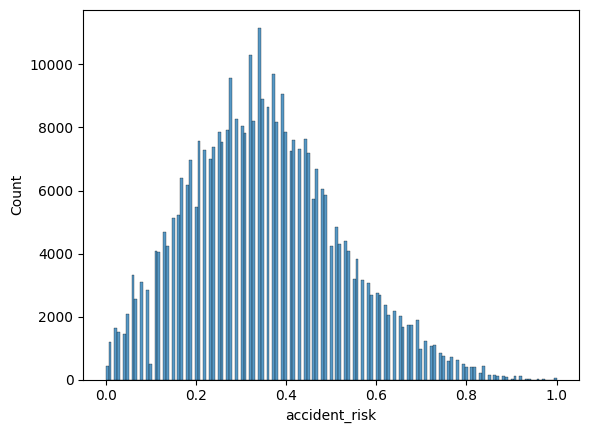

In [13]:
sns.histplot(y_train)

In [14]:
y_train.describe()

count    372782.000000
mean          0.352562
std           0.166425
min           0.000000
25%           0.230000
50%           0.340000
75%           0.460000
max           1.000000
Name: accident_risk, dtype: float64

Распределение симметричное, так как mean ~ median

## Коэффициент корреляции Пирсона между признаками и целевой переменной

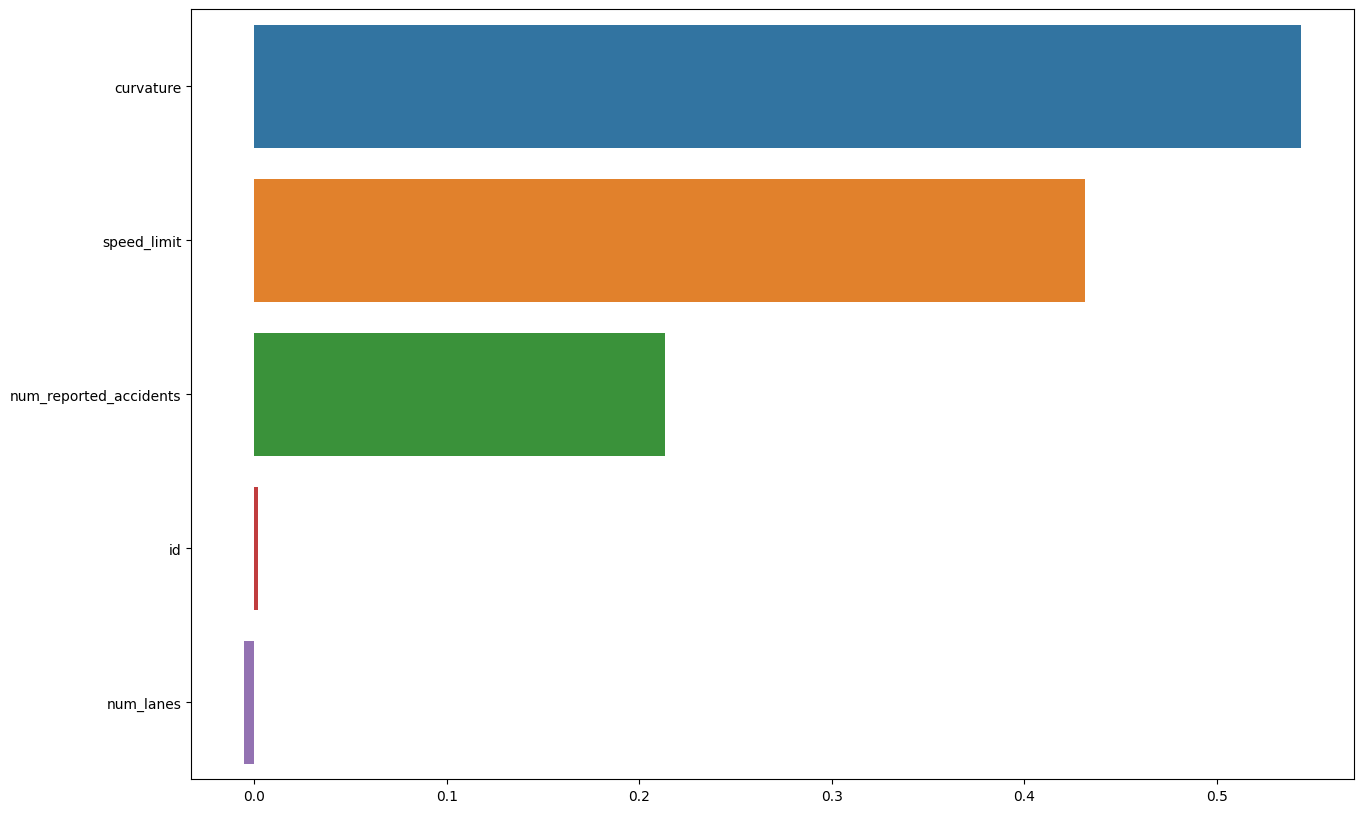

In [15]:
numeric_data = X_train.select_dtypes([np.number])
numeric_data_mean = numeric_data.mean()
numeric_features = numeric_data.columns

X_train = X_train.fillna(numeric_data_mean)

correlations = X_train[numeric_features].corrwith(y_train).sort_values(ascending=False)

plot = sns.barplot(y=correlations.index, x=correlations)
plot.figure.set_size_inches(15, 10)

In [16]:
test = test.fillna(numeric_data_mean)

1) *curvature* - имеет корреляцию > 0.5
2) *speed_limit* - имеет корреляцию > 0.4
3) *num_reported_acccidents* - имеет корреляцию > 0.2

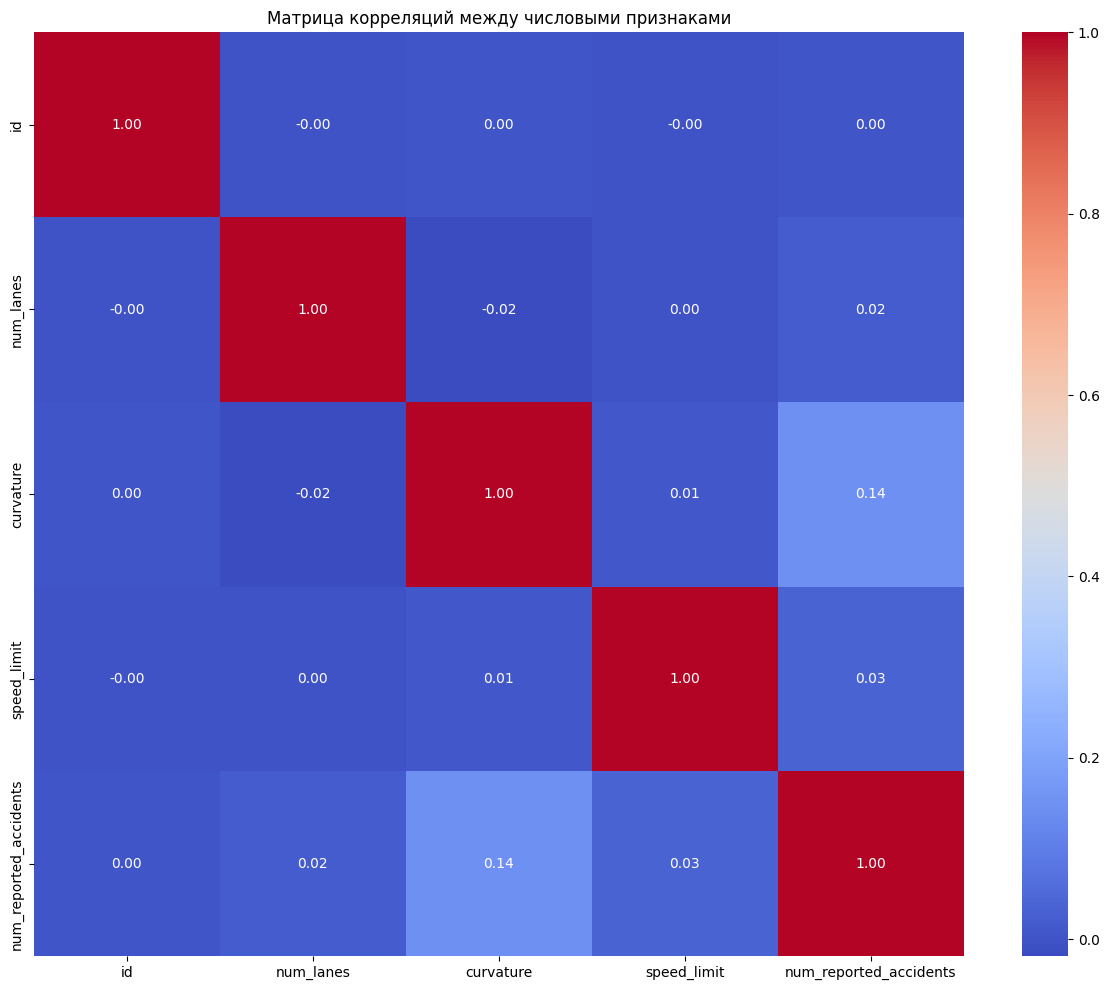

In [17]:
corr_matrix = X_train[numeric_features].corr()
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Матрица корреляций между числовыми признаками")
plt.show()

Мультиколлинеарности между числовыми признаками нет

## Feature Engeeniring

In [18]:
X_train.head()

,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents
20140,20140,highway,2,0.84,60,night,clear,False,False,morning,True,True,0
74157,74157,rural,1,0.68,70,night,foggy,False,False,morning,False,True,2
363865,363865,rural,1,0.68,60,daylight,foggy,False,False,afternoon,False,True,0
500981,500981,rural,3,0.76,25,night,foggy,True,False,afternoon,True,True,2
496714,496714,highway,4,0.21,70,night,rainy,True,True,evening,False,True,1


In [19]:
X_train['id'].isnull().sum()

0

## Удаление id

In [20]:
for data in [X_train, X_test, X_val, test]:
    data.drop(columns = ['id'], inplace = True)

## Обработка признака road_type

In [21]:
X_train['road_type'].dtypes

dtype('O')

In [22]:
X_train["road_type"].value_counts()

road_type
highway    125209
rural      124152
urban      123421
Name: count, dtype: int64

In [23]:
train = X_train.copy()
train['accident_risk'] = y_train

In [24]:
train.groupby("road_type")["accident_risk"].mean().sort_values(ascending = False)

road_type
urban      0.357762
rural      0.350110
highway    0.349867
Name: accident_risk, dtype: float64

Наибольший средний риск аварии имееет urban

**Обработать этот признак с помощью label encoding**

## Обработка признака num_lanes(кол-во полос на дороге)

In [25]:
X_train["num_lanes"].nunique()

4

In [26]:
train.groupby("num_lanes")["accident_risk"].mean().sort_values(ascending = False)

num_lanes
3    0.357460
2    0.354067
1    0.351297
4    0.347494
Name: accident_risk, dtype: float64

In [27]:
train.groupby(["num_lanes", "road_type"])["accident_risk"].mean().sort_values(ascending = False)

num_lanes  road_type
3          urban        0.361885
2          urban        0.359379
1          urban        0.355842
3          highway      0.355467
           rural        0.354973
4          urban        0.353925
2          rural        0.351625
           highway      0.351278
1          highway      0.349570
           rural        0.348548
4          rural        0.345412
           highway      0.343272
Name: accident_risk, dtype: float64

Можно попробовать сделать средний риск по комбинации num_lanes и road_type, так модель лучше поймёт зависимость

In [28]:
train.groupby(['curvature', "speed_limit"])["accident_risk"].mean().sort_values(ascending = False)

curvature  speed_limit
1.0000     60             0.698027
           70             0.654416
0.6216     60             0.630000
0.9100     60             0.629199
0.9300     60             0.626899
                            ...   
0.2351     45             0.130000
0.2927     35             0.130000
0.1300     35             0.126467
0.1139     25             0.110000
0.2921     35             0.100000
Name: accident_risk, Length: 671, dtype: float64

Кривизна дороги влияет 

In [29]:
X_train['lighting'].nunique()

3

In [30]:
train.groupby(["lighting", "speed_limit"])["accident_risk"].mean().sort_values(ascending = False)

lighting  speed_limit
night     60             0.636000
          70             0.604464
dim       60             0.409157
daylight  60             0.406871
night     45             0.406773
          35             0.406081
daylight  70             0.405719
dim       70             0.403287
night     25             0.403262
daylight  25             0.239316
dim       25             0.238624
          45             0.233875
daylight  45             0.232577
          35             0.229896
dim       35             0.228613
Name: accident_risk, dtype: float64

Ночью риск аварии выше

## Новый признак night_high_speed

In [31]:
for data in [X_train, X_test, X_val, test]:
    data["night_high_speed"] = ((data["lighting"] == "night") & (data["speed_limit"] >= 60)).astype(int)

In [32]:
train.groupby("weather")["accident_risk"].mean().sort_values(ascending = False)

weather
foggy    0.386708
rainy    0.361593
clear    0.310056
Name: accident_risk, dtype: float64

При туманной и дождливой погоде риск выше

In [33]:
train.groupby(["weather", "lighting"])["accident_risk"].mean().sort_values(ascending = False)

weather  lighting
foggy    night       0.514745
rainy    night       0.483659
clear    night       0.423891
foggy    daylight    0.339403
         dim         0.331081
rainy    dim         0.316883
         daylight    0.316214
clear    daylight    0.251235
         dim         0.248930
Name: accident_risk, dtype: float64

## lighting_weather

In [34]:
for data in [X_train, X_test, X_val, test]:
    data["lighting_weather"] = data["lighting"] + "_" + data["weather"]

In [35]:
train.groupby("road_signs_present")["accident_risk"].mean().sort_values(ascending = False)

road_signs_present
True     0.352686
False    0.352438
Name: accident_risk, dtype: float64

Наличие знака не влияет на риск аварии

In [36]:
X_train["road_signs_present"].value_counts()

road_signs_present
False    186858
True     185924
Name: count, dtype: int64

In [37]:
train['curvature'].describe()

count    372782.000000
mean          0.488486
std           0.272399
min           0.000000
25%           0.260000
50%           0.510000
75%           0.710000
max           1.000000
Name: curvature, dtype: float64

In [38]:
X_train.head()

,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,night_high_speed,lighting_weather
20140,highway,2,0.84,60,night,clear,False,False,morning,True,True,0,1,night_clear
74157,rural,1,0.68,70,night,foggy,False,False,morning,False,True,2,1,night_foggy
363865,rural,1,0.68,60,daylight,foggy,False,False,afternoon,False,True,0,0,daylight_foggy
500981,rural,3,0.76,25,night,foggy,True,False,afternoon,True,True,2,0,night_foggy
496714,highway,4,0.21,70,night,rainy,True,True,evening,False,True,1,1,night_rainy


In [39]:
train["public_road"].describe()

count     372782
unique         2
top         True
freq      186980
Name: public_road, dtype: object

In [40]:
pd.crosstab(X_train['lighting'], X_train['time_of_day'], normalize='index')

time_of_day,afternoon,evening,morning
lighting,,,
daylight,0.333601,0.334187,0.332212
dim,0.334070,0.331543,0.334388
night,0.327064,0.336272,0.336664


## lighting_time_of_day

In [41]:
for data in [X_train, X_test, X_val, test]:
    data["lighting_time_of_day"] = data["lighting"] + "_" + data["time_of_day"]

In [42]:
pd.crosstab(X_train['road_type'], X_train['lighting'], normalize='index')

lighting,daylight,dim,night
road_type,,,
highway,0.342603,0.355230,0.302167
rural,0.347501,0.358931,0.293568
urban,0.340874,0.349430,0.309696


## road_type_lighting

In [43]:
for data in [X_train, X_test, X_val, test]:
    data["road_type_lighting"] = data["road_type"] + "_" + data["lighting"]

In [44]:
train.groupby('holiday')['accident_risk'].mean()

holiday
False    0.344226
True     0.360775
Name: accident_risk, dtype: float64

In [45]:
pd.crosstab(df['holiday'], df['road_type'], normalize='index')

road_type,highway,rural,urban
holiday,,,
False,0.334241,0.334626,0.331133
True,0.336609,0.332574,0.330817


## holiday_road

In [46]:
for data in [X_train, X_test, X_val, test]:
    data['holiday_road'] = data['holiday'].astype(str) + "_" + data['road_type']

In [47]:
train.groupby('school_season')['accident_risk'].mean()

school_season
False    0.352976
True     0.352143
Name: accident_risk, dtype: float64

In [48]:
# school_season + road_type
train.groupby(['school_season','road_type'])['accident_risk'].mean()



school_season  road_type
False          highway      0.350332
               rural        0.350405
               urban        0.358269
True           highway      0.349398
               rural        0.349808
               urban        0.357252
Name: accident_risk, dtype: float64

In [49]:
train.groupby(['school_season','time_of_day'])['accident_risk'].mean()

school_season  time_of_day
False          afternoon      0.351892
               evening        0.355446
               morning        0.351548
True           afternoon      0.352039
               evening        0.354054
               morning        0.350385
Name: accident_risk, dtype: float64

## school_time

In [50]:
for data in [X_train, X_test, X_val, test]:
    data['school_time'] = data['school_season'].astype(str) + "_" + data['time_of_day']

## accidents_bin

In [51]:
for data in [X_train, X_test, X_val, test]:
    data['accidents_bin'] = pd.cut(data['num_reported_accidents'], bins=5, labels=False)
    data['accidents_speed'] = data['num_reported_accidents'] * data['speed_limit']

## Создание нового признака curvature_high

In [52]:
for data in [X_train, X_test, X_val, test]:
    data["curvature_high"] = (data['curvature'] > 0.71).astype(int)

## Создание признака speed_bin, разбиение по квартилям

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='speed_limit', ylabel='Count'>

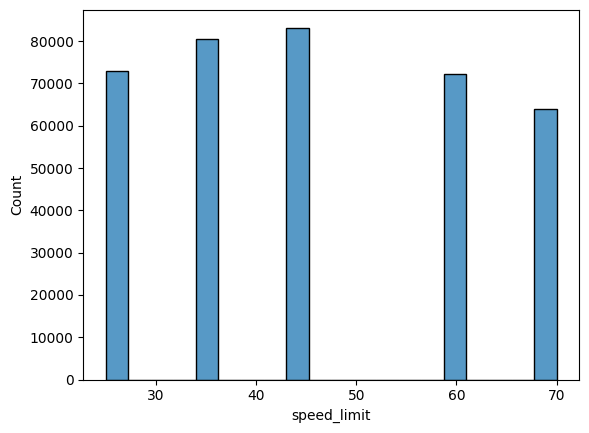

In [53]:
sns.histplot(X_train['speed_limit'], bins=20)

In [54]:
X_train['speed_limit'].describe()

count    372782.000000
mean         46.120561
std          15.790238
min          25.000000
25%          35.000000
50%          45.000000
75%          60.000000
max          70.000000
Name: speed_limit, dtype: float64

In [55]:
for data in [X_train, X_test, X_val, test]:
    data["speed_bin"] = pd.qcut(data["speed_limit"], q = 4, labels = False)

## Создание признака curvature_speed, lanes_speed, curvature_lanes

In [56]:
for data in [X_train, X_test, X_val, test]:
    data["curvature_speed"] = data["curvature"] * data["speed_limit"]
    data["lanes_speed"] = data["num_lanes"] * data["speed_limit"]
    data["curvature_lanes"] = data["curvature"] * data["num_lanes"]

In [57]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 372782 entries, 20140 to 16084
Data columns (total 25 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   road_type               372782 non-null  object 
 1   num_lanes               372782 non-null  int64  
 2   curvature               372782 non-null  float64
 3   speed_limit             372782 non-null  int64  
 4   lighting                372782 non-null  object 
 5   weather                 372782 non-null  object 
 6   road_signs_present      372782 non-null  bool   
 7   public_road             372782 non-null  bool   
 8   time_of_day             372782 non-null  object 
 9   holiday                 372782 non-null  bool   
 10  school_season           372782 non-null  bool   
 11  num_reported_accidents  372782 non-null  int64  
 12  night_high_speed        372782 non-null  int64  
 13  lighting_weather        372782 non-null  object 
 14  lighting_time_of_day  

In [58]:
cat_features = X_train.select_dtypes(include=['object']).columns.tolist()
print(cat_features)

['road_type', 'lighting', 'weather', 'time_of_day', 'lighting_weather', 'lighting_time_of_day', 'road_type_lighting', 'holiday_road', 'school_time']


## Подбор гиперпараметров

In [59]:
from catboost import CatBoostRegressor
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'depth': [4,5,6,7],
    'learning_rate': [0.01, 0.03, 0.05],
    'l2_leaf_reg': [3,5,7,9],
    'iterations': [500, 1000, 1500]
}

# Создаём модель с GPU
model = CatBoostRegressor(
    loss_function='RMSE',
    cat_features=cat_features,
    task_type='GPU',   # <-- включаем GPU
    devices='0',       # <-- используем первый GPU
    verbose=0
)

search = RandomizedSearchCV(
    model, 
    param_grid, 
    scoring='neg_root_mean_squared_error', 
    cv=3, 
    n_iter=10,
    verbose=2
)

search.fit(X_train, y_train)
print(search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END depth=7, iterations=500, l2_leaf_reg=5, learning_rate=0.03; total time=  19.0s
[CV] END depth=7, iterations=500, l2_leaf_reg=5, learning_rate=0.03; total time=  17.7s
[CV] END depth=7, iterations=500, l2_leaf_reg=5, learning_rate=0.03; total time=  17.9s
[CV] END depth=6, iterations=500, l2_leaf_reg=5, learning_rate=0.01; total time=  15.1s
[CV] END depth=6, iterations=500, l2_leaf_reg=5, learning_rate=0.01; total time=  15.2s
[CV] END depth=6, iterations=500, l2_leaf_reg=5, learning_rate=0.01; total time=  15.3s
[CV] END depth=5, iterations=500, l2_leaf_reg=7, learning_rate=0.01; total time=  12.6s
[CV] END depth=5, iterations=500, l2_leaf_reg=7, learning_rate=0.01; total time=  12.7s
[CV] END depth=5, iterations=500, l2_leaf_reg=7, learning_rate=0.01; total time=  12.9s
[CV] END depth=7, iterations=1000, l2_leaf_reg=3, learning_rate=0.05; total time=  35.3s
[CV] END depth=7, iterations=1000, l2_leaf_reg=3, learning

## Обучение модели CatBoost

In [60]:
from catboost import CatBoostRegressor

model = CatBoostRegressor(
    iterations=1000,       # количество деревьев
    learning_rate=0.05,    # скорость обучения
    depth=7,     
    l2_leaf_reg=9,
    eval_metric='RMSE',    # метрика для регрессии
    cat_features=cat_features,  # список категориальных признаков
    random_seed=42,
    verbose=100,            # каждые 100 итераций будет выводиться лог
    task_type='GPU',
    devices='0'
)

model.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),  # валидация для отслеживания RMSE
    use_best_model=True        # модель остановится на лучшей итерации
)

0:	learn: 0.1594958	test: 0.1599842	best: 0.1599842 (0)	total: 45.7ms	remaining: 45.7s
100:	learn: 0.0566488	test: 0.0562940	best: 0.0562940 (100)	total: 4.78s	remaining: 42.5s
200:	learn: 0.0563569	test: 0.0560574	best: 0.0560574 (200)	total: 9.4s	remaining: 37.4s
300:	learn: 0.0562087	test: 0.0559623	best: 0.0559623 (300)	total: 14s	remaining: 32.5s
400:	learn: 0.0561022	test: 0.0559080	best: 0.0559080 (400)	total: 18.6s	remaining: 27.8s
500:	learn: 0.0560129	test: 0.0558647	best: 0.0558647 (500)	total: 23.2s	remaining: 23.1s
600:	learn: 0.0559380	test: 0.0558413	best: 0.0558413 (600)	total: 27.9s	remaining: 18.5s
700:	learn: 0.0558726	test: 0.0558215	best: 0.0558215 (699)	total: 32.6s	remaining: 13.9s
800:	learn: 0.0558157	test: 0.0558050	best: 0.0558050 (800)	total: 37.1s	remaining: 9.22s
900:	learn: 0.0557555	test: 0.0557924	best: 0.0557924 (899)	total: 41.7s	remaining: 4.58s
999:	learn: 0.0557018	test: 0.0557810	best: 0.0557810 (998)	total: 46.3s	remaining: 0us
bestTest = 0.05578

In [61]:
from sklearn.metrics import mean_squared_error
import numpy as np  # если np ещё не импортирован
y_pred_val = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
print(f"RMSE на валидации: {rmse:.4f}")

RMSE на валидации: 0.0558


In [62]:
y_pred_test = model.predict(X_test)

In [63]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
print(f"RMSE на тесте: {rmse:.4f}")

RMSE на тесте: 0.0563


In [64]:
y_pred_test_2 = model.predict(test)

In [65]:

# заменяем колонку с предсказаниями на свои
submission['accident_risk'] = y_pred_test_2

# сохраняем результат
submission.to_csv('submission.csv', index=False)